In [1]:
import pandas as pd
import numpy as np

## Verify Relationships Using Python

In [2]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")
payments = pd.read_csv("payments.csv")
reviews = pd.read_csv("reviews.csv")
sellers = pd.read_csv("sellers.csv")

### Check Customers → Orders

In [3]:
orders["customer_id"].isin(
    customers["customer_id"]
).all()

np.True_

### Check Orders → Order Items

In [4]:
order_items["order_id"].isin(
    orders["order_id"]
).all()

np.True_

### Check Products

In [5]:
order_items["product_id"].isin(
    products["product_id"]
).all()

np.True_

### Check Sellers

In [6]:
order_items["seller_id"].isin(
    sellers["seller_id"]
).all()

np.True_

### Check Payments

In [7]:
payments["order_id"].isin(
    orders["order_id"]
).all()

np.True_

## data cleaning

### Initial Data Quality Check

In [8]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews,
    "sellers": sellers
}

for name, df in tables.items():
    print(f"\n{'='*50}")
    print(name.upper())
    print('='*50)

    print("Shape:", df.shape)
    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())

    print("\nData Types:")
    print(df.dtypes)


CUSTOMERS
Shape: (10300, 8)

Missing Values:
customer_id             0
customer_unique_id      0
customer_zip_code     306
customer_city         504
customer_state          0
signup_date           298
gender                  0
age                     0
dtype: int64

Duplicate Rows: 300

Data Types:
customer_id               str
customer_unique_id        str
customer_zip_code     float64
customer_city             str
customer_state            str
signup_date               str
gender                    str
age                     int64
dtype: object

ORDERS
Shape: (30600, 8)

Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     2101
order_delivered_customer_date    2101
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows: 600

Data Types:
order_id                         str
customer_id   

### Check Missing Values

In [9]:
customers.isnull().sum()
orders.isnull().sum()
order_items.isnull().sum()
products.isnull().sum()
payments.isnull().sum()
reviews.isnull().sum()
sellers.isnull().sum()

seller_id           0
seller_zip_code    18
seller_city        16
seller_state        0
dtype: int64

### Check Duplicate Records

In [10]:
for name, df in tables.items():
    print(name, ":", df.duplicated().sum())

customers : 300
orders : 600
order_items : 917
products : 100
payments : 734
reviews : 612
sellers : 15


### Inspect Column Types

In [11]:
for name, df in tables.items():
    print("\n", name)
    print(df.info())


 customers
<class 'pandas.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         10300 non-null  str    
 1   customer_unique_id  10300 non-null  str    
 2   customer_zip_code   9994 non-null   float64
 3   customer_city       9796 non-null   str    
 4   customer_state      10300 non-null  str    
 5   signup_date         10002 non-null  str    
 6   gender              10300 non-null  str    
 7   age                 10300 non-null  int64  
dtypes: float64(1), int64(1), str(6)
memory usage: 643.9 KB
None

 orders
<class 'pandas.DataFrame'>
RangeIndex: 30600 entries, 0 to 30599
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       30600 non-null  str  
 1   customer_id                    30600 non-null  str 

### Check Unique Values in Categorical Columns

### For customers:

In [12]:
customers["gender"].value_counts(dropna=False)

gender
male      1781
Female    1738
FEMALE    1708
MALE      1698
female    1688
Male      1687
Name: count, dtype: int64

### For orders:

In [13]:
orders["order_status"].value_counts()

order_status
delivered     21503
shipped        3023
processing     2412
cancelled      2101
invoiced       1561
Name: count, dtype: int64

### For payments:

In [14]:
payments["payment_type"].value_counts()

payment_type
credit_card      7132
upi              7057
net_banking      7031
wallet           7024
debit_card       6987
 net_banking       88
 upi               78
 credit_card       75
 debit_card        75
NET_BANKING        74
DEBIT_CARD         73
UPI                71
CREDIT_CARD        70
 wallet            68
WALLET             60
Name: count, dtype: int64

### For products:

In [15]:
products["product_category_name"].nunique()

36

### Step 2.6 — Check Numeric Data Issues

In [16]:
customers.describe()
payments.describe()
order_items.describe()
reviews.describe()

,review_score
count,31212.000000
mean,2.951461
std,1.462544
min,-1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


### removing duplicates

In [17]:
customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()
products = products.drop_duplicates()
payments = payments.drop_duplicates()
reviews = reviews.drop_duplicates()
sellers = sellers.drop_duplicates()

In [18]:
print(customers.duplicated().sum())
print(orders.duplicated().sum())
print(order_items.duplicated().sum())
print(products.duplicated().sum())
print(payments.duplicated().sum())
print(reviews.duplicated().sum())
print(sellers.duplicated().sum())

0
0
0
0
0
0
0


### 2. Customers Table Cleaning

In [19]:
customers["customer_zip_code"] = customers["customer_zip_code"].fillna(
    customers["customer_zip_code"].median()
)

In [20]:
customers["customer_city"] = customers["customer_city"].fillna(
    customers["customer_city"].mode()[0]
)

In [21]:
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

In [22]:
customers["signup_date"] = customers["signup_date"].fillna(
    customers["signup_date"].median()
)

### 3. Standardize Gender Column

In [23]:
customers["gender"] = (
    customers["gender"]
    .str.strip()
    .str.lower()
)

In [24]:
customers["gender"].value_counts()

gender
male      5010
female    4990
Name: count, dtype: int64

### 4. Age Validation

In [25]:
customers["age"].describe()

count    10000.000000
mean        42.352200
std         17.740277
min         -5.000000
25%         29.000000
50%         42.000000
75%         54.000000
max        150.000000
Name: age, dtype: float64

In [26]:
customers[
    (customers["age"] < 18) |
    (customers["age"] > 100)
]

,customer_id,customer_unique_id,customer_zip_code,customer_city,customer_state,signup_date,gender,age
0,CUST00001,UNQ00001,258183.0,Phagwara,Maharashtra,2024-11-10,female,-5
14,CUST00015,UNQ00015,778855.0,TIRUVOTTIYUR,Haryana,2024-04-03,male,120
18,CUST00019,UNQ00019,179019.0,Madurai,Telangana,2025-04-14,male,150
26,CUST00027,UNQ00027,253690.0,Ambarnath,Manipur,2024-10-24,male,150
43,CUST00044,UNQ00044,934046.0,guwahati,Gujarat,2025-05-30,female,-5
...,...,...,...,...,...,...,...,...
9673,CUST09674,UNQ09674,399067.0,Khammam,Meghalaya,2024-04-28,male,-5
9745,CUST09746,UNQ09746,553244.0,bhopal,Punjab,2025-02-03,male,120
9795,CUST09796,UNQ09796,743097.0,Adoni,Sikkim,2025-02-01,female,120
9831,CUST09832,UNQ09832,537730.0,Jhansi,Mizoram,2024-02-02,male,120


In [27]:
customers.loc[
    (customers["age"] < 18) |
    (customers["age"] > 100),
    "age"
] = customers["age"].median()

In [28]:
customers["age"].describe()

count    10000.000000
mean        41.534300
std         13.705481
min         18.000000
25%         30.000000
50%         42.000000
75%         53.000000
max         65.000000
Name: age, dtype: float64

### 5. Orders Table Cleaning

### Convert Date Columns

In [29]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [30]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [31]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

### 6. Order Items Cleaning

In [32]:
order_items["price"].describe()

count    89826.000000
mean      2553.174542
std       1414.876285
min        100.140000
25%       1329.290000
50%       2546.285000
75%       3785.340000
max       4999.860000
Name: price, dtype: float64

In [33]:
order_items["price"] = order_items["price"].fillna(
    order_items["price"].median()
)

In [34]:
order_items[
    (order_items["price"] <= 0) |
    (order_items["freight_value"] < 0)
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


### 7. Products Cleaning

In [35]:
products["product_category_name"] = products[
    "product_category_name"
].fillna("unknown")

In [36]:
products["product_length_cm"] = products[
    "product_length_cm"
].fillna(products["product_length_cm"].median())

products["product_height_cm"] = products[
    "product_height_cm"
].fillna(products["product_height_cm"].median())

products["product_width_cm"] = products[
    "product_width_cm"
].fillna(products["product_width_cm"].median())

In [37]:
### 8. Payments Cleaning

In [38]:
payments["payment_type"] = (
    payments["payment_type"]
    .str.strip()
    .str.lower()
)

In [39]:
payments["payment_type"] = payments[
    "payment_type"
].fillna("unknown")

In [40]:
payments["payment_type"].value_counts()

payment_type
credit_card    7277
upi            7206
net_banking    7193
wallet         7152
debit_card     7135
unknown         734
Name: count, dtype: int64

### 9. Reviews Cleaning

In [41]:
reviews["review_comment_title"] = reviews[
    "review_comment_title"
].fillna("No Title")

reviews["review_comment_message"] = reviews[
    "review_comment_message"
].fillna("No Comment")

In [42]:
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"],
    errors="coerce"
)

### 10. Sellers Cleaning

In [43]:
sellers["seller_zip_code"] = sellers[
    "seller_zip_code"
].fillna(
    sellers["seller_zip_code"].median()
)

sellers["seller_city"] = sellers[
    "seller_city"
].fillna(
    sellers["seller_city"].mode()[0]
)

In [44]:
customers.to_csv("customers_clean.csv", index=False)
orders.to_csv("orders_clean.csv", index=False)
order_items.to_csv("order_items_clean.csv", index=False)
products.to_csv("products_clean.csv", index=False)
payments.to_csv("payments_clean.csv", index=False)
reviews.to_csv("reviews_clean.csv", index=False)
sellers.to_csv("sellers_clean.csv", index=False)

### Check Invalid Review Scores

In [45]:
reviews[reviews["review_score"] < 1]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
38,REV347056,ORD000039,-1,Average Experience,Would definitely buy again.,2024-06-28 15:54:54,2024-06-29 16:54:54
40,REV703273,ORD000041,-1,Satisfied,Would definitely buy again.,2024-06-28 19:33:41,2024-06-30 08:33:41
56,REV173839,ORD000057,-1,Excellent Product,Amazing experience and good quality.,2025-04-20 15:32:59,2025-04-21 20:32:59
71,REV184523,ORD000072,-1,Highly Recommended,Product quality is excellent and delivery was ...,2026-03-29 13:35:48,2026-03-31 15:35:48
127,REV574398,ORD000128,-1,Not Bad,Customer service was helpful.,2024-09-06 14:47:37,2024-09-08 13:47:37
...,...,...,...,...,...,...,...
30308,REV657572,ORD009304,-1,Excellent Product,Very satisfied with the purchase.,2025-02-14 21:02:12,2025-02-15 13:02:12
30315,REV589956,ORD009190,-1,Very Good,Product quality is excellent and delivery was ...,2026-06-03 01:54:28,2026-06-03 10:54:28
30461,REV641325,ORD016602,-1,Average Experience,Customer service was helpful.,2024-10-26 13:48:22,2024-10-27 08:48:22
30504,REV491086,ORD028356,-1,Satisfied,Very satisfied with the purchase.,2026-05-20 05:21:05,2026-05-21 03:21:05


In [46]:
reviews["review_score"].value_counts().sort_index()

review_score
-1     306
 1    6116
 2    6070
 3    5999
 4    6136
 5    5973
Name: count, dtype: int64

In [47]:
(reviews["review_score"] < 1).sum()

np.int64(306)

In [48]:
median_score = reviews.loc[
    reviews["review_score"] >= 1,
    "review_score"
].median()

reviews.loc[
    reviews["review_score"] < 1,
    "review_score"
] = median_score

In [49]:
reviews["review_score"].describe()

count    30600.000000
mean         2.992810
std          1.406827
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: review_score, dtype: float64

#### Before moving to Phase 3 (Data Transformation)

#### Run these and send me the results:

In [50]:
customers["age"].describe()
order_items["price"].describe()
payments["payment_value"].describe()
reviews["review_score"].describe()

count    30600.000000
mean         2.992810
std          1.406827
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: review_score, dtype: float64

In [51]:
print("AGE")
print(customers["age"].describe())

print("\nPRICE")
print(order_items["price"].describe())

print("\nPAYMENT VALUE")
print(payments["payment_value"].describe())

print("\nREVIEW SCORE")
print(reviews["review_score"].describe())

AGE
count    10000.000000
mean        41.534300
std         13.705481
min         18.000000
25%         30.000000
50%         42.000000
75%         53.000000
max         65.000000
Name: age, dtype: float64

PRICE
count    91659.000000
mean      2553.036765
std       1400.657641
min        100.140000
25%       1353.540000
50%       2546.285000
75%       3762.440000
max       4999.860000
Name: price, dtype: float64

PAYMENT VALUE
count    36697.000000
mean      4179.720528
std       2923.969495
min       -100.000000
25%       1578.290000
50%       3763.360000
75%       6591.870000
max       9999.630000
Name: payment_value, dtype: float64

REVIEW SCORE
count    30600.000000
mean         2.992810
std          1.406827
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: review_score, dtype: float64


#### Also check for invalid values

In [52]:
print("Negative ages:", (customers["age"] < 0).sum())
print("Age > 100:", (customers["age"] > 100).sum())

print("Price <= 0:", (order_items["price"] <= 0).sum())

print("Payment <= 0:", (payments["payment_value"] <= 0).sum())

Negative ages: 0
Age > 100: 0
Price <= 0: 0
Payment <= 0: 368


#### Fix Payment Values

In [53]:
payments[payments["payment_value"] <= 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
69,ORD000055,1,upi,1,-100.0
88,ORD000072,1,upi,1,-100.0
108,ORD000090,1,credit_card,9,-100.0
541,ORD000437,1,debit_card,1,-100.0
627,ORD000509,1,debit_card,1,-100.0
...,...,...,...,...,...
36310,ORD021740,1,upi,1,-100.0
36325,ORD015694,2,wallet,1,-100.0
36460,ORD012394,1,net_banking,1,-100.0
36525,ORD009843,1,credit_card,4,-100.0


In [54]:
payments["payment_value"].describe()

count    36697.000000
mean      4179.720528
std       2923.969495
min       -100.000000
25%       1578.290000
50%       3763.360000
75%       6591.870000
max       9999.630000
Name: payment_value, dtype: float64

In [55]:
payments = payments[payments["payment_value"] > 0]

In [56]:
(payments["payment_value"] <= 0).sum()

np.int64(0)

In [57]:
customers.to_csv("customers_clean.csv", index=False)
orders.to_csv("orders_clean.csv", index=False)
order_items.to_csv("order_items_clean.csv", index=False)
products.to_csv("products_clean.csv", index=False)
payments.to_csv("payments_clean.csv", index=False)
reviews.to_csv("reviews_clean.csv", index=False)
sellers.to_csv("sellers_clean.csv", index=False)

### PHASE 3 — DATA TRANSFORMATION

### Total Order Value

In [58]:
order_items["item_total"] = (
    order_items["price"] +
    order_items["freight_value"]
)

In [59]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total
0,ORD000001,1,PROD03340,SELL0319,2026-01-04 08:56:14,4370.90,309.90,4680.80
1,ORD000001,2,PROD04013,SELL0167,2026-01-05 08:56:14,161.25,20.48,181.73
2,ORD000001,3,PROD01532,SELL0384,2026-01-08 08:56:14,2135.03,224.74,2359.77
3,ORD000001,4,PROD04212,SELL0299,2026-01-07 08:56:14,3747.98,481.04,4229.02
4,ORD000002,1,PROD03394,SELL0045,2026-04-09 04:47:38,910.00,73.19,983.19


### Delivery Delay

In [60]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

In [61]:
orders["delivery_delay_days"].describe()

count    27943.000000
mean        -2.501879
std          1.700708
min         -5.000000
25%         -4.000000
50%         -2.000000
75%         -1.000000
max          0.000000
Name: delivery_delay_days, dtype: float64

### Step 3: Purchase Month

In [62]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.month
)

### Step 4: Purchase Year

In [63]:
orders["purchase_year"] = (
    orders["order_purchase_timestamp"]
    .dt.year
)

### Step 5: Purchase Quarter

In [64]:
orders["purchase_quarter"] = (
    orders["order_purchase_timestamp"]
    .dt.quarter
)

### Step 6: Customer Age Groups

In [65]:
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18,25,35,45,55,65,100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

In [66]:
customers["age_group"].value_counts()

age_group
36-45    2247
46-55    2074
56-65    2030
26-35    2025
18-25    1416
65+         0
Name: count, dtype: int64

### Step 7: Create Monthly Sales Table

In [67]:
sales_df = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

### Monthly revenue:

In [68]:
monthly_sales = (
    sales_df
    .groupby(
        ["purchase_year","purchase_month"]
    )["item_total"]
    .sum()
    .reset_index()
)

In [69]:
monthly_sales.head()

,purchase_year,purchase_month,item_total
0,2024,5,3.605384e+06
1,2024,6,1.057072e+07
2,2024,7,1.074539e+07
3,2024,8,1.132554e+07
4,2024,9,1.085187e+07


### Step 8: Create Customer Summary Table

In [70]:
customer_summary = (
    sales_df
    .groupby("customer_id")
    .agg(
        total_orders=("order_id","nunique"),
        total_spent=("item_total","sum")
    )
    .reset_index()
)

### Step 9: Create Product Summary Table

In [71]:
product_summary = (
    sales_df
    .groupby("product_id")
    .agg(
        quantity_sold=("order_item_id","count"),
        revenue=("item_total","sum")
    )
    .reset_index()
)

### Step 10: RFM Preparation (Very Important)

In [72]:
snapshot_date = (
    orders["order_purchase_timestamp"]
    .max()
)

In [73]:
rfm = (
    sales_df
    .groupby("customer_id")
    .agg(
        Recency=(
            "order_purchase_timestamp",
            lambda x:
            (snapshot_date - x.max()).days
        ),
        Frequency=("order_id","nunique"),
        Monetary=("item_total","sum")
    )
    .reset_index()
)

In [74]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,378,3,22028.18
1,CUST00002,705,2,12288.41
2,CUST00003,311,2,20617.16
3,CUST00004,83,5,47458.64
4,CUST00005,262,3,24719.40


In [75]:
monthly_sales.head()

,purchase_year,purchase_month,item_total
0,2024,5,3.605384e+06
1,2024,6,1.057072e+07
2,2024,7,1.074539e+07
3,2024,8,1.132554e+07
4,2024,9,1.085187e+07


In [76]:
customer_summary.head()

,customer_id,total_orders,total_spent
0,CUST00001,3,22028.18
1,CUST00002,2,12288.41
2,CUST00003,2,20617.16
3,CUST00004,5,47458.64
4,CUST00005,3,24719.40


In [77]:
product_summary.head()

,product_id,quantity_sold,revenue
0,PROD00001,24,68561.360
1,PROD00002,19,61649.545
2,PROD00003,20,44504.210
3,PROD00004,14,35732.385
4,PROD00005,16,46263.240


In [78]:
monthly_sales.columns

Index(['purchase_year', 'purchase_month', 'item_total'], dtype='str')

In [79]:
monthly_sales.head()

,purchase_year,purchase_month,item_total
0,2024,5,3.605384e+06
1,2024,6,1.057072e+07
2,2024,7,1.074539e+07
3,2024,8,1.132554e+07
4,2024,9,1.085187e+07


### Save Cleaned Files

In [80]:
customers.to_csv("customers_clean.csv", index=False)
orders.to_csv("orders_clean.csv", index=False)
order_items.to_csv("order_items_clean.csv", index=False)
products.to_csv("products_clean.csv", index=False)
payments.to_csv("payments_clean.csv", index=False)
reviews.to_csv("reviews_clean.csv", index=False)
sellers.to_csv("sellers_clean.csv", index=False)

# EDA(EXPLORATRY DATA ANALYSIS )

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### LOEAD

In [82]:
customers = pd.read_csv("customers_clean.csv")
orders = pd.read_csv("orders_clean.csv")
order_items = pd.read_csv("order_items_clean.csv")
products = pd.read_csv("products_clean.csv")
payments = pd.read_csv("payments_clean.csv")
reviews = pd.read_csv("reviews_clean.csv")

### Create sales_df

In [83]:
sales_df = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

### Create monthly_sales

In [84]:
monthly_sales = (
    sales_df
    .groupby(["purchase_year", "purchase_month"])["item_total"]
    .sum()
    .reset_index()
)

In [85]:
monthly_sales.head()

,purchase_year,purchase_month,item_total
0,2024,5,3.605384e+06
1,2024,6,1.057072e+07
2,2024,7,1.074539e+07
3,2024,8,1.132554e+07
4,2024,9,1.085187e+07


### Create customer_summary

In [86]:
customer_summary = (
    sales_df
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_spent=("item_total", "sum")
    )
    .reset_index()
)

In [87]:
customer_summary.head()

,customer_id,total_orders,total_spent
0,CUST00001,3,22028.18
1,CUST00002,2,12288.41
2,CUST00003,2,20617.16
3,CUST00004,5,47458.64
4,CUST00005,3,24719.40


### Create product_summary

In [88]:
product_summary = (
    sales_df
    .groupby("product_id")
    .agg(
        quantity_sold=("order_item_id", "count"),
        revenue=("item_total", "sum")
    )
    .reset_index()
)

In [89]:
product_summary.head()

,product_id,quantity_sold,revenue
0,PROD00001,24,68561.360
1,PROD00002,19,61649.545
2,PROD00003,20,44504.210
3,PROD00004,14,35732.385
4,PROD00005,16,46263.240


### Create rfm

In [163]:
sales_df["order_purchase_timestamp"] = pd.to_datetime( #Converts purchase date column into datetime format.
    sales_df["order_purchase_timestamp"]
)

In [91]:
sales_df["order_purchase_timestamp"].dtype

dtype('<M8[us]')

In [162]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

snapshot_date = orders["order_purchase_timestamp"].max()

rfm = (
    sales_df                                      # start creating rfm from sales table 
    .groupby("customer_id")                      # Groups all transactions customer-wise.                                 
    .agg(                                        # Performs calculations for each customer.
        Recency=(                                 # Uses purchase date column for Recency calculation.
            "order_purchase_timestamp",
            lambda x: (snapshot_date - x.max()).days  # lambda x use for lates date (finding)
        ),
        Frequency=("order_id", "nunique"),       #Counts unique orders for each customer.
        Monetary=("item_total", "sum")            # Adds total money spent by customer.
    )
    .reset_index()        #Converts grouped customer_id back into normal column
)

In [93]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,378,3,22028.18
1,CUST00002,705,2,12288.41
2,CUST00003,311,2,20617.16
3,CUST00004,83,5,47458.64
4,CUST00005,262,3,24719.40


In [94]:
monthly_sales.to_csv("monthly_sales.csv", index=False)
customer_summary.to_csv("customer_summary.csv", index=False)
product_summary.to_csv("product_summary.csv", index=False)
rfm.to_csv("rfm.csv", index=False)

### EDA 1 — Monthly Revenue Trend

### Business Question
### Is revenue growing or declining?

### EDA 2 — Top 10 Products by Revenue

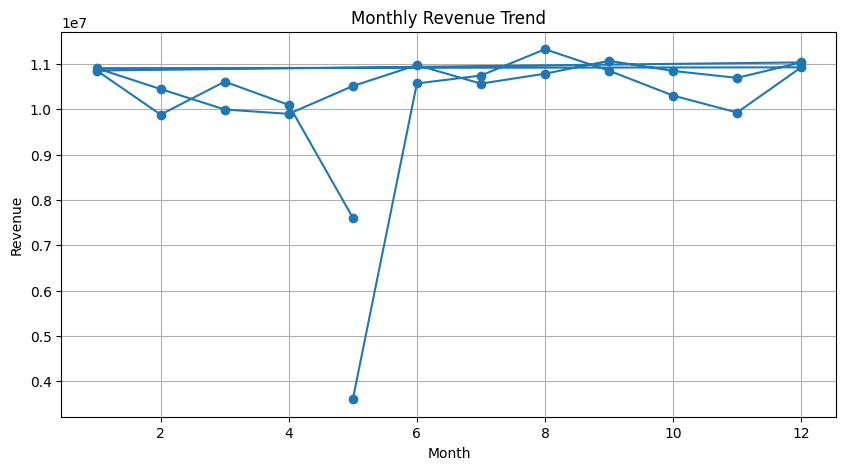

In [95]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["purchase_month"],
    monthly_sales["item_total"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

### EDA 2 — Top 10 Products by Revenue

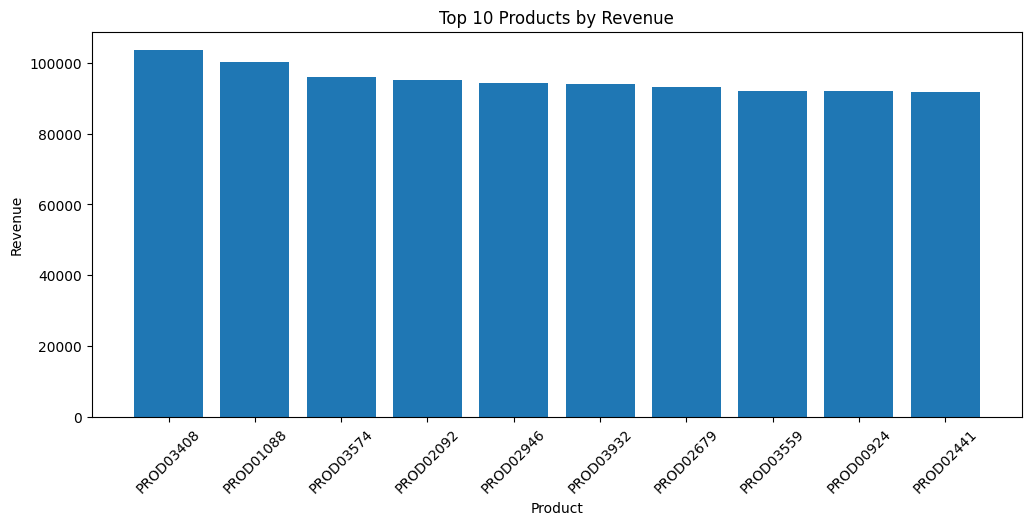

In [96]:
top_products = (
    product_summary
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

plt.bar(
    top_products["product_id"],
    top_products["revenue"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

### EDA 3 — Top 10 Products by Quantity Sold

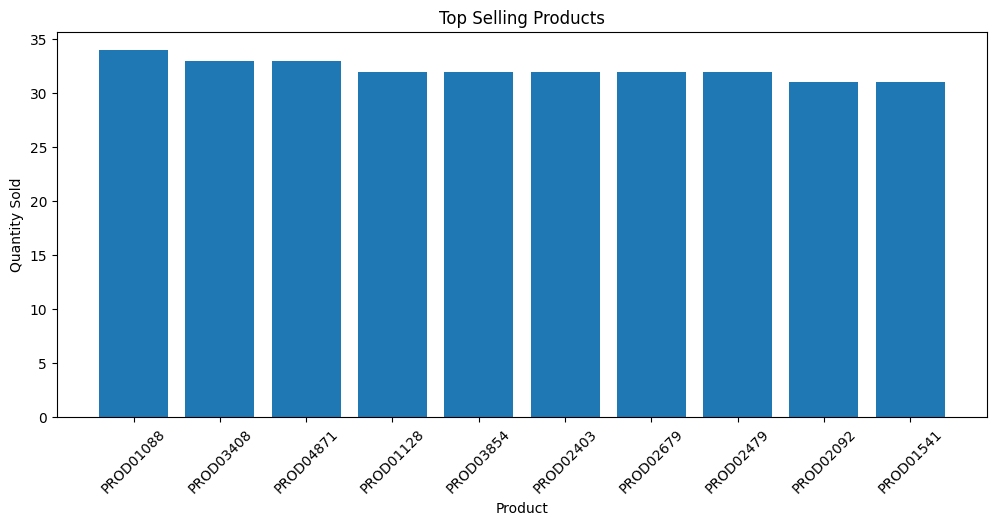

In [97]:
top_qty = (
    product_summary
    .sort_values("quantity_sold", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

plt.bar(
    top_qty["product_id"],
    top_qty["quantity_sold"]
)

plt.xticks(rotation=45)

plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

### EDA 4 — Revenue by Category

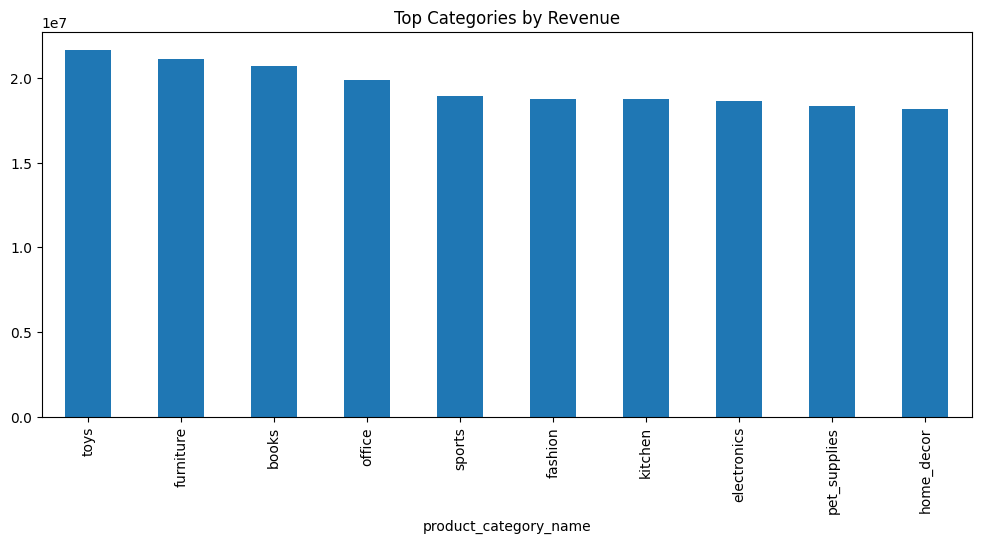

In [98]:
category_sales = (
    order_items
    .merge(products,on="product_id")
    .groupby("product_category_name")
    ["item_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

category_sales.plot(kind="bar")

plt.title("Top Categories by Revenue")

plt.show()

### EDA 5 — Customer Age Group Distribution

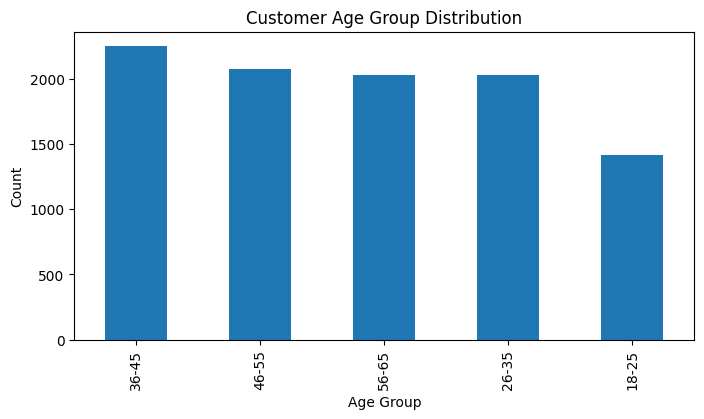

In [99]:
customers["age_group"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

### EDA 6 — Gender Distribution

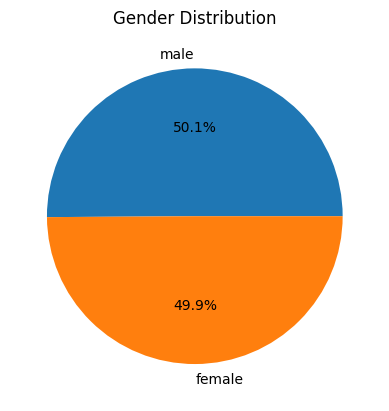

In [100]:
customers["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

### EDA 7 — Payment Method Analysis

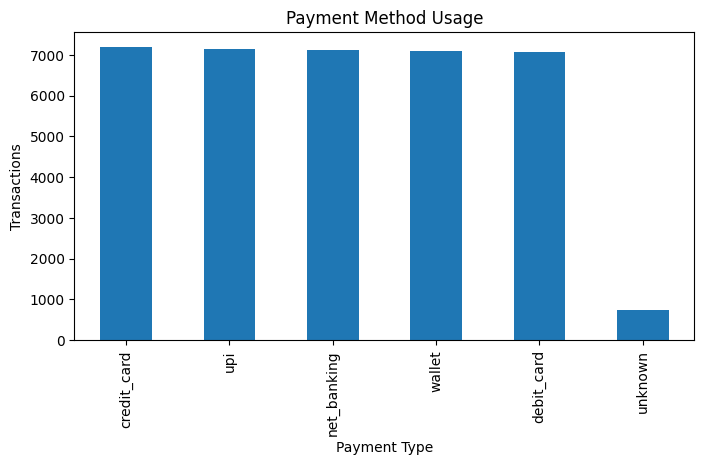

In [101]:
payments["payment_type"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Type")
plt.ylabel("Transactions")

plt.show()

### EDA 8 — Review Score Distribution

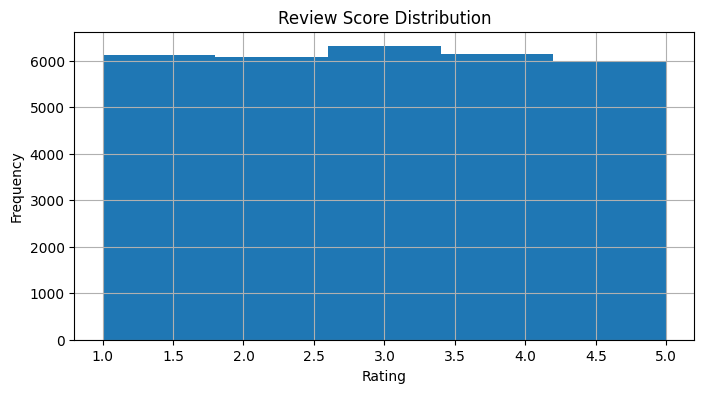

In [102]:
plt.figure(figsize=(8,4))

reviews["review_score"].hist(
    bins=5
)

plt.title("Review Score Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

### EDA 9 — Delivery Status Analysis

In [103]:
import numpy as np

orders["delivery_status"] = np.where(
    orders["delivery_delay_days"] > 0,
    "Late",
    np.where(
        orders["delivery_delay_days"] == 0,
        "On Time",
        "Early"
    )
)

In [104]:
orders["delivery_status"].value_counts()

delivery_status
Early      25402
On Time     4598
Name: count, dtype: int64

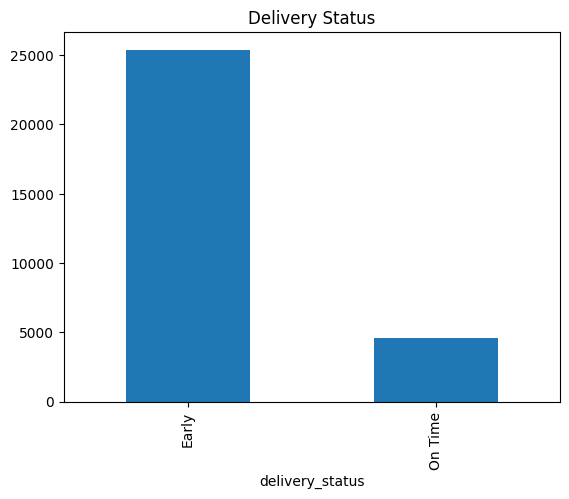

In [105]:
orders["delivery_status"].value_counts().plot(
    kind="bar"
)

plt.title("Delivery Status")

plt.show()

### EDA 10 — Customer Spending Distribution

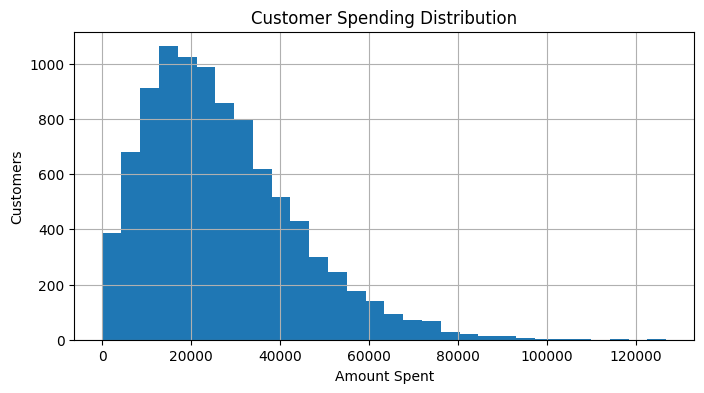

In [106]:
plt.figure(figsize=(8,4))

customer_summary["total_spent"].hist(
    bins=30
)

plt.title("Customer Spending Distribution")
plt.xlabel("Amount Spent")
plt.ylabel("Customers")

plt.show()

### EDA 11 — Correlation Analysis (Heatmap)

In [107]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


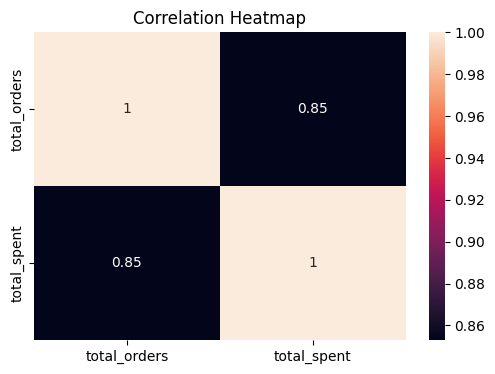

In [108]:
import seaborn as sns

corr_df = customer_summary[
    ["total_orders","total_spent"]
]

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

# churn predication 

In [109]:
import pandas as pd

churn_prediction = pd.read_csv("churn_prediction.csv")

In [110]:
churn_prediction.head()

,customer_id,churn_probability,churn_risk
0,CUST00002,0.0721,Low
1,CUST00003,0.1789,Low
2,CUST00004,0.2679,Low
3,CUST00005,NaN,Low
4,CUST00007,0.3897,Low


### 1. Distribution of Risk Levels

In [111]:
churn_prediction["churn_risk"].value_counts()

churn_risk
Low         6547
Medium      2235
High         595
 Low          75
LOW           71
low           55
 Medium       22
MEDIUM        19
medium        19
 High          9
high           8
HIGH           7
Name: count, dtype: int64

### 2. Percentage of Each Risk Level

In [112]:
churn_prediction["churn_risk"].value_counts(normalize=True) * 100

churn_risk
Low         67.760298
Medium      23.131857
High         6.158145
 Low         0.776237
LOW          0.734838
low          0.569240
 Medium      0.227696
MEDIUM       0.196647
medium       0.196647
 High        0.093148
high         0.082799
HIGH         0.072449
Name: proportion, dtype: float64

### 3. Top High-Risk Customers

In [113]:
churn_prediction.sort_values(
    by="churn_probability",
    ascending=False
).head(10)

,customer_id,churn_probability,churn_risk
2751,CUST02894,2.0,Low
5853,CUST06183,2.0,Low
5930,CUST06265,2.0,Low
4168,CUST04394,2.0,Low
1685,CUST01769,2.0,Low
4016,CUST04232,2.0,Low
4133,CUST04356,2.0,Medium
2653,CUST02792,2.0,Medium
6097,CUST06439,2.0,Low
8278,CUST08749,2.0,Low


### 4. Average Churn Probability

In [114]:
churn_prediction["churn_probability"].mean()

np.float64(0.34560242872228086)

### 5. Check Missing Values

In [115]:
churn_prediction.isnull().sum()

customer_id            0
churn_probability    192
churn_risk             0
dtype: int64

### missing row

In [116]:
churn_prediction[
    churn_prediction["churn_probability"].isna()
].head()

,customer_id,churn_probability,churn_risk
3,CUST00005,NaN,Low
106,CUST00113,NaN,Low
131,CUST00139,NaN,Low
265,CUST00275,NaN,Low
315,CUST00326,NaN,Low


### fix missing row

In [117]:
churn_prediction["churn_probability"] = (
    churn_prediction["churn_probability"]
    .fillna(0)
)

In [118]:
churn_prediction.isnull().sum()

customer_id          0
churn_probability    0
churn_risk           0
dtype: int64

In [119]:
churn_prediction.to_csv(
    "churn_prediction_clean.csv",
    index=False
)

## Create Visualizations
### Churn Risk Distribution

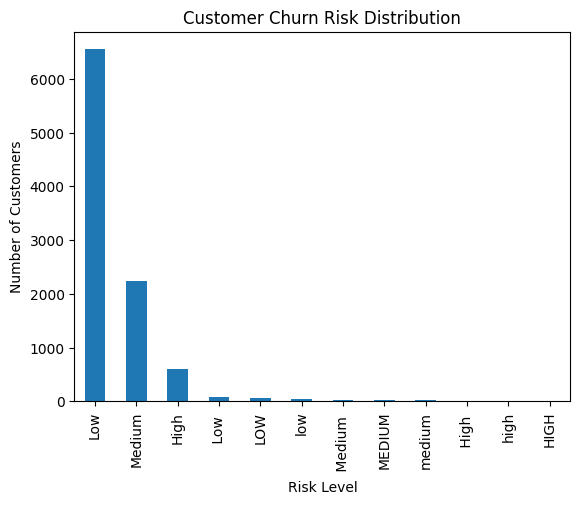

In [120]:
import matplotlib.pyplot as plt

churn_prediction["churn_risk"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

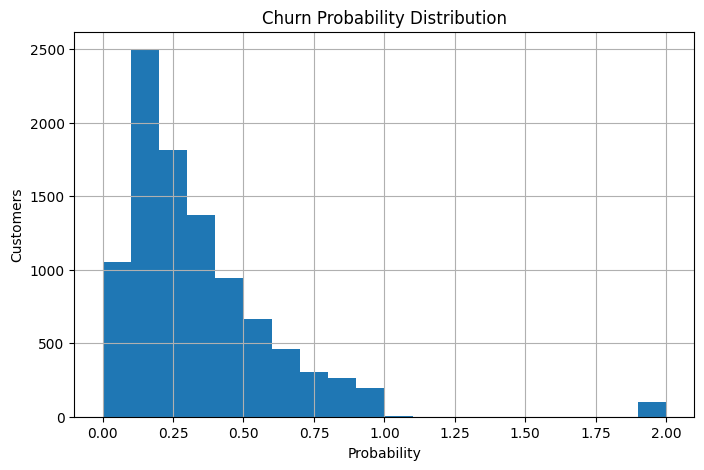

In [121]:
plt.figure(figsize=(8,5))

churn_prediction["churn_probability"].hist(
    bins=20
)

plt.title("Churn Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Customers")

plt.show()

## Churn Prediction Model Development
### Step 1 — Check Available Data

In [122]:
customer_summary = pd.read_csv("customer_summary.csv") 

customer_summary.head()

,customer_id,total_orders,total_spent
0,CUST00001,3,22028.18
1,CUST00002,2,12288.41
2,CUST00003,2,20617.16
3,CUST00004,5,47458.64
4,CUST00005,3,24719.40


In [123]:
customer_summary.columns

Index(['customer_id', 'total_orders', 'total_spent'], dtype='str')

In [124]:
### rfm

In [125]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,CUST00001,378,3,22028.18
1,CUST00002,705,2,12288.41
2,CUST00003,311,2,20617.16
3,CUST00004,83,5,47458.64
4,CUST00005,262,3,24719.40


In [126]:
rfm["churn"] = (            # Creates a new column named:
    rfm["Recency"] > 90     # customer inactive(1) if ts > 90 days othevise(0) 
).astype(int)               

In [127]:
rfm["churn"].value_counts() # total churn and non churn customer 

churn
1    6358
0    3104
Name: count, dtype: int64

In [128]:
### praper feature

In [129]:
X = rfm[["Recency", "Frequency", "Monetary"]] # create input variable 
y = rfm["churn"]                              # output variable

print(X.head())
print(y.head())

   Recency  Frequency  Monetary
0      378          3  22028.18
1      705          2  12288.41
2      311          2  20617.16
3       83          5  47458.64
4      262          3  24719.40
0    1
1    1
2    1
3    0
4    1
Name: churn, dtype: int64


### Step 2 — Train/Test Split

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7569, 3)
X_test : (1893, 3)
y_train: (7569,)
y_test : (1893,)


### Step 3 — Feature Scaling

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 2.26246011 -0.6900188  -0.41134043]
 [ 2.094097   -0.6900188  -0.61746685]
 [-0.59971281 -0.6900188  -0.61061853]
 [ 0.12018464 -0.6900188  -0.37299842]
 [-0.88418842  0.49548848 -0.07902816]]


### Step 4 — Train Logistic Regression Model

In [132]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()  #Creates a Logistic Regression model object. beacouse it give result in yes/no mean 0/1

lr.fit(
    X_train_scaled,       # Trains the Logistic Regression model using training data.
    y_train
)

print("Model trained successfully!")

Model trained successfully!


### Step 5 — Make Predictions

In [133]:
y_pred_lr = lr.predict(X_test_scaled)

print(y_pred_lr[:10])

[1 1 0 1 0 1 0 1 0 1]


### Step 6 — Evaluate the Model

In [134]:
from sklearn.metrics import accuracy_score, classification_report  # import 2 fun 1(calculate overall accuracy) 2(give detailed performance)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_lr)     # accuracy calculation (actual value, predicat value)
)

print(
    classification_report(               # these gives the detailed info 
        y_test,
        y_pred_lr
    )
)

Accuracy: 0.9957739038563127
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       621
           1       1.00      0.99      1.00      1272

    accuracy                           1.00      1893
   macro avg       0.99      1.00      1.00      1893
weighted avg       1.00      1.00      1.00      1893



### Step 7 — Confusion Matrix

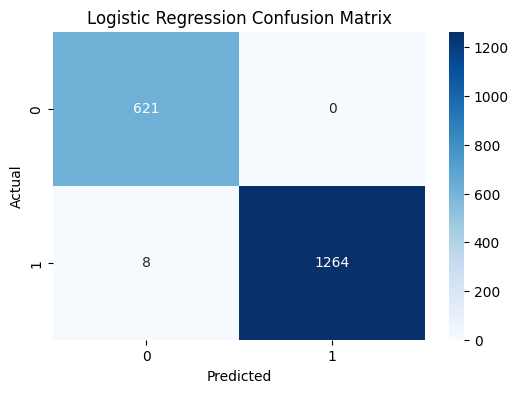

In [135]:
from sklearn.metrics import confusion_matrix  #library(create confusion matrix)
import seaborn as sns                         #library(makes visulixzation)
import matplotlib.pyplot as plt                #visualization

cm = confusion_matrix(                        #The function compares them and creates a matrix.
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))                     #graph

sns.heatmap(                                  #the visualization confusion matrix
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(                                      
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")              
plt.ylabel("Actual")

plt.show()

### Customer-wise Churn Prediction Function

In [136]:
def predict_customer_churn(customer_id):

    customer = rfm[                              #➡ Displays error message if customer is not available.
        rfm["customer_id"] == customer_id
    ]

    if customer.empty:                           # ➡ check is exist or not
        print("Customer ID not found!")
        return

    customer_features = customer[                 #➡ Selects RFM values used for churn prediction.
        ["Recency", "Frequency", "Monetary"]
    ]

    customer_scaled = scaler.transform(           #➡ Applies StandardScaler to convert data into the same scale used during training.
        customer_features
    )

    prediction = lr.predict(                     # Uses Logistic Regression model to predict churn.(lr)
        customer_scaled
    )[0]

    probability = lr.predict_proba(             # Calculates churn probability percentage.
        customer_scaled
    )[0][1]

    print("Customer ID:", customer_id)          # Displays entered customer ID.

    if prediction == 1:
        print("Prediction: Customer Will Churn")
    else:
        print("Prediction: Customer Will Not Churn")

    print(
        "Churn Probability:",
        round(probability * 100, 2),
        "%"
    )

In [137]:
predict_customer_churn("CUST00001")

Customer ID: CUST00001
Prediction: Customer Will Churn
Churn Probability: 100.0 %


In [138]:
predict_customer_churn("CUST00009")

Customer ID: CUST00009
Prediction: Customer Will Not Churn
Churn Probability: 0.01 %


# Phase 8 — Sales Forecasting

### Step 1 — Check Monthly Sales Dataset

In [139]:
monthly_sales.head()

,purchase_year,purchase_month,item_total
0,2024,5,3.605384e+06
1,2024,6,1.057072e+07
2,2024,7,1.074539e+07
3,2024,8,1.132554e+07
4,2024,9,1.085187e+07


In [140]:
monthly_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   purchase_year   25 non-null     int64  
 1   purchase_month  25 non-null     int64  
 2   item_total      25 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 732.0 bytes


In [141]:
monthly_sales.shape

(25, 3)

### Step 2 — Create a Proper Date Column

In [142]:
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["purchase_year"].astype(str)
    + "-"
    + monthly_sales["purchase_month"].astype(str)
    + "-01"
)

monthly_sales.head()

,purchase_year,purchase_month,item_total,Date
0,2024,5,3.605384e+06,2024-05-01
1,2024,6,1.057072e+07,2024-06-01
2,2024,7,1.074539e+07,2024-07-01
3,2024,8,1.132554e+07,2024-08-01
4,2024,9,1.085187e+07,2024-09-01


### Step 3 — Sort by Date

In [143]:
monthly_sales = monthly_sales.sort_values(
    by="Date"
)

monthly_sales = monthly_sales.reset_index(
    drop=True
)

monthly_sales[["Date","item_total"]].head()

,Date,item_total
0,2024-05-01,3.605384e+06
1,2024-06-01,1.057072e+07
2,2024-07-01,1.074539e+07
3,2024-08-01,1.132554e+07
4,2024-09-01,1.085187e+07


### Step 4 — Visualize Monthly Sales Trend

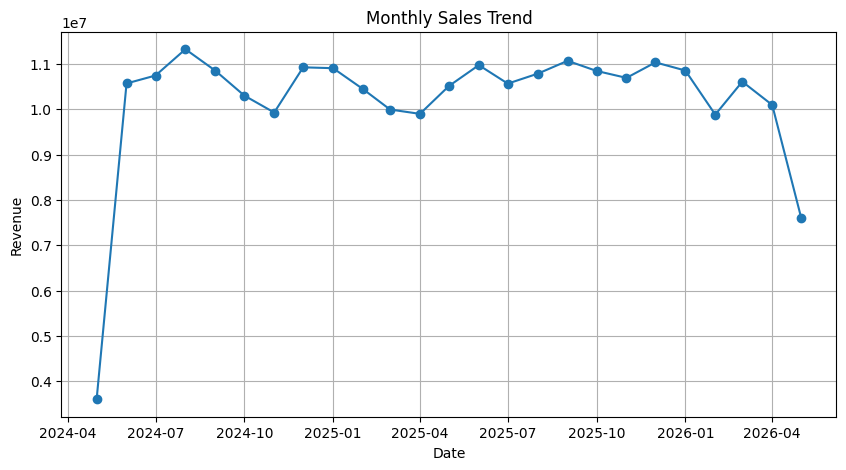

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["item_total"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Step 5 — Create Time Index Feature

In [145]:
monthly_sales["Month_Number"] = range(
    1,
    len(monthly_sales) + 1
)

monthly_sales[
    ["Date","Month_Number","item_total"]
].head()

,Date,Month_Number,item_total
0,2024-05-01,1,3.605384e+06
1,2024-06-01,2,1.057072e+07
2,2024-07-01,3,1.074539e+07
3,2024-08-01,4,1.132554e+07
4,2024-09-01,5,1.085187e+07


### Step 6 — Define X and y

In [146]:
X = monthly_sales[["Month_Number"]]

y = monthly_sales["item_total"]

print(X.head())
print(y.head())

   Month_Number
0             1
1             2
2             3
3             4
4             5
0    3.605384e+06
1    1.057072e+07
2    1.074539e+07
3    1.132554e+07
4    1.085187e+07
Name: item_total, dtype: float64


### Step 7 — Train Linear Regression Model

In [147]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

print("Sales Forecasting Model Trained Successfully!")

Sales Forecasting Model Trained Successfully!


### Step 8 — Predict Sales for Existing Months

In [148]:
monthly_sales["Predicted_Sales"] = model.predict(X)

monthly_sales[
    ["Date", "item_total", "Predicted_Sales"]
].head()

,Date,item_total,Predicted_Sales
0,2024-05-01,3.605384e+06,9.816830e+06
1,2024-06-01,1.057072e+07,9.848919e+06
2,2024-07-01,1.074539e+07,9.881009e+06
3,2024-08-01,1.132554e+07,9.913099e+06
4,2024-09-01,1.085187e+07,9.945188e+06


### Step 9 — Plot Actual vs Predicted Sales

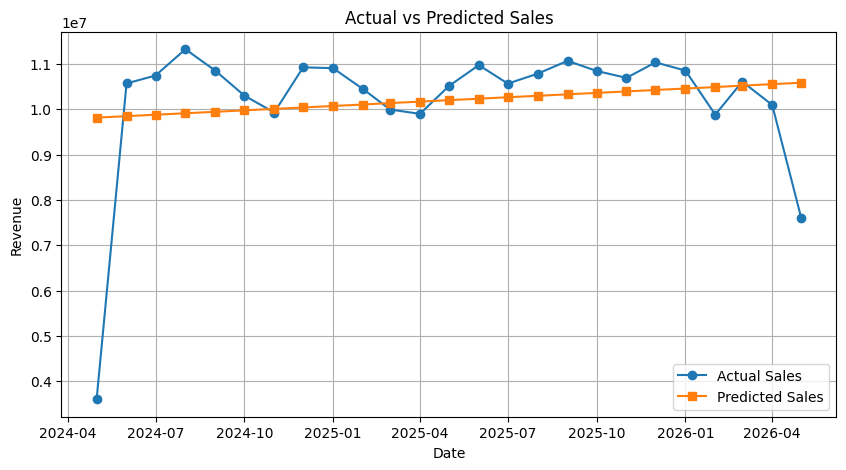

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["item_total"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Predicted_Sales"],
    marker="s",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

### Step 10 — Calculate Model Accuracy (R² Score)

In [150]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y,
    monthly_sales["Predicted_Sales"]
)

print("R² Score:", round(r2, 4))

R² Score: 0.0232


#### Next Step — Forecast Future Sales Anyway

In [151]:
future_months = pd.DataFrame({
    "Month_Number": range(
        len(monthly_sales) + 1,
        len(monthly_sales) + 7
    )
})

future_months["Forecasted_Sales"] = model.predict(
    future_months
)

future_months

,Month_Number,Forecasted_Sales
0,26,1.061907e+07
1,27,1.065116e+07
2,28,1.068325e+07
3,29,1.071534e+07
4,30,1.074743e+07
5,31,1.077952e+07


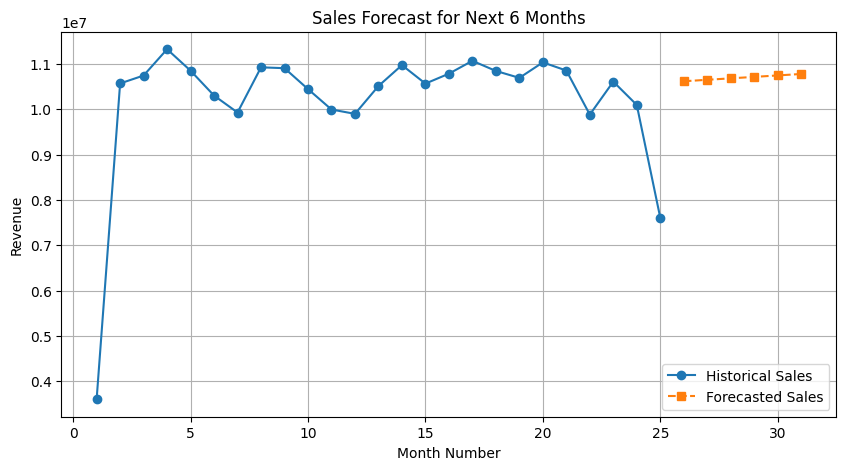

In [152]:
plt.figure(figsize=(10,5))

# Historical Sales
plt.plot(
    monthly_sales["Month_Number"],
    monthly_sales["item_total"],
    marker="o",
    label="Historical Sales"
)

# Forecast Sales
plt.plot(
    future_months["Month_Number"],
    future_months["Forecasted_Sales"],
    marker="s",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Sales Forecast for Next 6 Months")
plt.xlabel("Month Number")
plt.ylabel("Revenue")

plt.legend()
plt.grid(True)

plt.show()

#### So we can create a function where you enter a future year and month and it predicts sales.

In [153]:
def predict_sales(year, month):   # ➡ Creates a function for predicting future sales revenue using year and month

    start_year = monthly_sales["purchase_year"].min()    #➡ Finds the earliest year available in the monthly sales dataset.
    start_month = monthly_sales["purchase_month"].min()  #➡ Finds the earliest month available in the dataset.

    month_number = (                                     
        (year - start_year) * 12
        + month
        - start_month
        + 1
    )

    forecast = model.predict                           #Uses trained Linear Regression model to predict revenue.
        pd.DataFrame(                                  #Creates dataframe input for model prediction.
            {"Month_Number": [month_number]}            #Passes calculated month number to the model.
        )
    )[0]                                                 # Retrieves predicted revenue value.

    current_revenue = monthly_sales["item_total"].iloc[-1] # Retrieves latest/current revenue value from dataset.

    print(f"Forecast for {month}/{year}")                    # Displays selected forecasting date.
    print("-" * 40)

    print(                                                   # Displays current revenue value.
        f"Current Revenue     : ₹{current_revenue:,.2f}"
    )

    print(
        f"Forecasted Revenue  : ₹{forecast:,.2f}"            #Displays predicted future revenue.
    )

    difference = forecast - current_revenue                  #Calculates increase or decrease in revenue.

    print(
        f"Difference          : ₹{difference:,.2f}"         #Displays revenue difference
    )

In [154]:
predict_sales(2026, 7)
predict_sales(2027, 6)
predict_sales(2028, 1)

Forecast for 7/2026
----------------------------------------
Current Revenue     : ₹7,608,288.69
Forecasted Revenue  : ₹10,779,520.34
Difference          : ₹3,171,231.65
Forecast for 6/2027
----------------------------------------
Current Revenue     : ₹7,608,288.69
Forecasted Revenue  : ₹11,132,506.90
Difference          : ₹3,524,218.21
Forecast for 1/2028
----------------------------------------
Current Revenue     : ₹7,608,288.69
Forecasted Revenue  : ₹11,357,134.71
Difference          : ₹3,748,846.02


## Product Recommendation System

In [155]:
products = pd.read_csv("products_clean.csv")

products.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,PROD00001,office,54,318,3,9788.68,54.78,23.03,14.40
1,PROD00002,automotive,32,1798,6,4719.24,6.77,39.64,39.90
2,PROD00003,automotive,78,1256,9,1955.36,70.46,43.95,14.48
3,PROD00004,home_decor,13,1501,6,8929.37,8.25,36.38,56.39
4,PROD00005,fashion,77,1405,1,7169.34,14.28,42.27,68.58


In [156]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_length',
       'product_description_length', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')

In [157]:
### dataset doesn't contain actual product names or stock quantities, we'll create a demo mapping for categories and generate stock values.

In [158]:
import numpy as np

products["stock_quantity"] = np.random.randint(
    50,
    500,
    size=len(products)
)

In [159]:
category_examples = {
    "electronics": [
        "Smartphone",
        "Laptop",
        "Tablet",
        "Smart Watch",
        "Bluetooth Speaker"
    ],

    "fashion": [
        "T-Shirt",
        "Jeans",
        "Jacket",
        "Sneakers",
        "Handbag"
    ],

    "home_decor": [
        "Wall Clock",
        "Table Lamp",
        "Decorative Vase",
        "Curtains",
        "Photo Frame"
    ],

    "office": [
        "Office Chair",
        "Study Desk",
        "Notebook",
        "Printer",
        "File Organizer"
    ],

    "automotive": [
        "Car Charger",
        "Seat Cover",
        "Bike Helmet",
        "Car Vacuum Cleaner",
        "GPS Navigator"
    ]
}

### recommendation function:

In [160]:
def recommend_products(product_id):  # Creates a function for recommending similar products using Product ID.

    product = products[
        products["product_id"] == product_id        # ➡ Searches the products dataset for the entered Product ID.
    ]

    if product.empty:
        print("Product ID not found!")          # Checks whether the product exists in the dataset.
        return

    category = product.iloc[0]["product_category_name"]  # ➡ Retrieves category of selected product.

    print(f"Product ID: {product_id}")                   # ➡ Displays selected Product ID.
    print(f"Category: {category.title()}")               # ➡ Displays product category name in proper format.
    print("\nRecommended Products\n")                    # ➡ Displays heading for recommendation output.

    if category not in category_examples:              # ➡ Checks whether recommendations are available for that category.
        print("No recommendations available")          # ➡ Displays message if category recommendations are unavailable.
        return

    names = category_examples[category]                 # ➡ Retrieves predefined product names for selected category.

    similar_products = products[                        # ➡ Finds first 5 products from the same category.
        products["product_category_name"] == category
    ].head(5)

    for (_, row), name in zip(                          # ➡ Loops through recommended products and product names together.
        similar_products.iterrows(),
        names
    ):

        print(                                      
            f"{row['product_id']} | "                   # Product ID
            f"{name} | "                                # Product Name
            f"Stock: {row['stock_quantity']}"           # Stock Quantity
        )

In [161]:
recommend_products("PROD00005")

Product ID: PROD00005
Category: Fashion

Recommended Products

PROD00005 | T-Shirt | Stock: 432
PROD00021 | Jeans | Stock: 221
PROD00037 | Jacket | Stock: 331
PROD00044 | Sneakers | Stock: 444
PROD00052 | Handbag | Stock: 196
